# Path-CBRP time sweep: profit shortfall vs budget

This notebook reads sweep CSVs from the parent directory (`external/CBRP_original/`) and plots a **custom profit gap** (not CPLEX `relativeGAP`).

## Reference profit \(P^\*\) (per CSV file)

1. If any row has `terminal == "all_positive_profit_blocks"`, then \(P^\* = \max(\text{cost})\) over those rows.
2. Else (e.g. sweep stopped on `max_T` while already serving all positive-profit blocks): \(P^\* = \max(\text{cost})\) over rows with `num_serviced_blocks == num_positive_profit_blocks`.
3. Else: \(P^\* = \max(\text{cost})\) over the whole file and a **warning** is printed (degenerate case).

Example: `notified-alto-santo-1000-2019.csv` ends with `terminal=max_T` but the last rows already achieve full positive coverage; rule (2) still yields the same \(P^\*\) as the plateau profit.

## Profit gap (per row)

For row profit \(P_t = \text{cost}\):

$$\text{profit\_gap} = \frac{P^* - P_t}{P^*} \quad \text{(NaN if } P^*=0\text{)}$$

Rows with `terminal == "error"` are excluded from aggregation plots.

## Aggregation

- **Binned curve (default):** 5-minute bins on `budget_T`, mean (and std band) of `profit_gap` across all instance-rows in each bin.
- **Relative budget:** per CSV, \(T / T_{\max}\) within that file; mean ± std line curves and optional **box plots** per relative bin (width `REL_BIN_WIDTH`) or at exact \(\tau\) values shared by ≥ `MIN_FILES` files.
- **Exact-T curve:** mean gap only at `budget_frac` values that appear in at least `MIN_FILES` CSVs (reduces sparse noise).
- **Case table:** `case_name`, `T_max` (max `budget_T` in file), `P_star` per sweep file.
- **Budget-to-ε profiles (option 3):** \(\tau_{\varepsilon,i} = \min\{\,T/T_{\max} : \text{profit\_gap}_i(T) \le \varepsilon\,\}\) from the full sweep. **CDF plot:** x = τ threshold, y = % of instances with \(\tau_{\varepsilon,i} \le x\) (one curve per ε). **Ratio plot:** when ≥2 methods are loaded, x = \(\kappa = \tau_{\varepsilon,i,m}/\min_{m'}\tau_{\varepsilon,i,m'}\), y = % of instances (Dolan–Moré style).
- **PGFPlots export:** after the binned absolute-budget plot, writes `profit_gap_binned.tex` + CSV (mean line + `fill between` for ±1 std; y-axis 0 = best at top).

In [1]:
import re
import warnings
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# CSVs live next to this reports/ folder
DATA_DIR = Path("..").resolve()
#GLOB_PATTERN = "notified-alto-santo-*.csv"
GLOB_PATTERN = "solutions/brkga-notified-limoeiro-*.*"
METHOD_LABEL = "BRKGA" if "brkga" in GLOB_PATTERN.lower() else Path(GLOB_PATTERN).stem
BIN_MINUTES = 5.0
MIN_FILES_FOR_EXACT_T = 3
REL_BIN_WIDTH = 0.02  # fraction of per-file T_max

# Budget-to-epsilon performance profiles (option 3)
GAP_EPSILONS = [0.0, 0.05, 0.10, 0.20]
GAP_TOL = 1e-9
TAU_EPS_IF_UNREACHABLE = 1.0
RATIO_PROFILE_LOG_X = False  # log-x for Dolan-More ratio plots when >= 2 methods

# PGFPlots / TikZ export (mean gap vs budget + std band)
EXPORT_PGFPLOTS = True
PGFPLOTS_TEX_PATH = Path("profit_gap_binned.tex")
PGFPLOTS_CSV_PATH = Path("profit_gap_binned.csv")
PGFPLOTS_METHOD_TEX = r"\textsc{" + METHOD_LABEL + "}"

In [2]:
STEM_RE = re.compile(
    #r"^notified-alto-santo-(?P<size>1000|2000|3000)-(?P<year>20\d{2})\.csv$"
    #r"^brkga-notified-limoeiro-(?P<size>1000|2000|3000)-(?P<year>20\d{2})\.csv$"
    r"^brkga-notified-limoeiro-(?P<size>1000|2000|3000)-(?P<year>20\d{2})\.(csv|txt)$"
)


def parse_stem(path: Path) -> Optional[Tuple[str, str]]:
    m = STEM_RE.match(path.name)
    if not m:

        return None
    return m.group("size"), m.group("year")


def reference_profit(df: pd.DataFrame, stem: str) -> Tuple[float, str]:
    """Return (P_star, rule_name)."""
    cost = pd.to_numeric(df["cost"], errors="coerce")
    df = df.assign(_cost=cost)
    ok = df[df["terminal"] == "all_positive_profit_blocks"]
    if len(ok) > 0:
        return float(ok["_cost"].max()), "terminal_success"
    mask_full = df["num_serviced_blocks"] == df["num_positive_profit_blocks"]
    sub = df[mask_full]
    if len(sub) > 0:
        return float(sub["_cost"].max()), "max_cost_when_fully_positive"
    warnings.warn(f"{stem}: no success row; P* = max(cost) over entire file")
    return float(df["_cost"].max()), "max_cost_fallback"


def load_sweep_csvs(
    data_dir: Path,
    glob_pattern: str = GLOB_PATTERN,
    method_label: str = METHOD_LABEL,
) -> pd.DataFrame:
    paths = sorted(data_dir.glob(glob_pattern))
    frames: List[pd.DataFrame] = []
    for p in paths:
        meta = parse_stem(p)
        if meta is None:
            continue
        size, year = meta
        raw = pd.read_csv(p)
        p_star, rule = reference_profit(raw, p.name)
        raw["source_file"] = p.name
        raw["method"] = method_label
        raw["size"] = size
        raw["year"] = int(year)
        raw["P_star"] = p_star
        raw["P_star_rule"] = rule
        frames.append(raw)
    if not frames:
        raise FileNotFoundError(f"No CSVs matching {glob_pattern} under {data_dir}")
    out = pd.concat(frames, ignore_index=True)
    return out


# Single method (default). For ratio profiles, concat multiple loads, e.g.:
# frames = [
#     load_sweep_csvs(DATA_DIR, "solutions/brkga-notified-limoeiro-*.*", "BRKGA"),
#     load_sweep_csvs(DATA_DIR, "solutions/path-notified-limoeiro-*.*", "Path"),
# ]
# df_raw = pd.concat(frames, ignore_index=True)

df_raw = load_sweep_csvs(DATA_DIR)
print(f"Loaded {df_raw['source_file'].nunique()} files, {len(df_raw)} rows")
print(df_raw.groupby("source_file")["P_star"].first().sort_index().to_string())

Loaded 18 files, 837 rows
source_file
brkga-notified-limoeiro-1000-2016.txt      127.0
brkga-notified-limoeiro-1000-2017.txt      245.0
brkga-notified-limoeiro-1000-2018.txt      253.0
brkga-notified-limoeiro-1000-2019.txt      337.0
brkga-notified-limoeiro-1000-2020.txt      899.0
brkga-notified-limoeiro-1000-2021.txt      921.0
brkga-notified-limoeiro-2000-2016.txt     1673.0
brkga-notified-limoeiro-2000-2017.txt     2603.0
brkga-notified-limoeiro-2000-2018.txt     2686.0
brkga-notified-limoeiro-2000-2019.txt     4334.0
brkga-notified-limoeiro-2000-2020.txt    10848.0
brkga-notified-limoeiro-2000-2021.txt    11490.0
brkga-notified-limoeiro-3000-2016.txt     1688.0
brkga-notified-limoeiro-3000-2017.txt     2577.0
brkga-notified-limoeiro-3000-2018.txt     2656.0
brkga-notified-limoeiro-3000-2019.txt     4280.0
brkga-notified-limoeiro-3000-2020.txt    10822.0
brkga-notified-limoeiro-3000-2021.txt    11529.0


In [3]:
df = df_raw.copy()
df["P_t"] = pd.to_numeric(df["cost"], errors="coerce")
df = df[df["terminal"] != "error"].copy()

df["profit_gap"] = np.where(
    df["P_star"] > 0,
    (df["P_star"] - df["P_t"]) / df["P_star"],
    np.nan,
)
# Numerical noise: clip tiny negatives to 0
df["profit_gap"] = df["profit_gap"].clip(lower=0.0)

df["budget_bin"] = (np.floor(df["budget_T"] / BIN_MINUTES) * BIN_MINUTES).astype(float)

# Relative budget within each sweep file: T / max(T) for that source_file
df["budget_frac"] = df["budget_T"] / df.groupby("source_file")["budget_T"].transform("max")

df[["budget_T", "P_t", "P_star", "profit_gap", "terminal", "source_file", "size", "year"]]

,budget_T,P_t,P_star,profit_gap,terminal,source_file,size,year
0,5.0,32.0,127.0,0.748031,NaN,brkga-notified-limoeiro-1000-2016.txt,1000,2016
1,10.0,48.0,127.0,0.622047,NaN,brkga-notified-limoeiro-1000-2016.txt,1000,2016
2,15.0,62.0,127.0,0.511811,NaN,brkga-notified-limoeiro-1000-2016.txt,1000,2016
3,20.0,77.0,127.0,0.393701,NaN,brkga-notified-limoeiro-1000-2016.txt,1000,2016
4,25.0,90.0,127.0,0.291339,NaN,brkga-notified-limoeiro-1000-2016.txt,1000,2016
...,...,...,...,...,...,...,...,...
832,460.0,11488.0,11529.0,0.003556,NaN,brkga-notified-limoeiro-3000-2021.txt,3000,2021
833,465.0,11505.0,11529.0,0.002082,NaN,brkga-notified-limoeiro-3000-2021.txt,3000,2021
834,470.0,11515.0,11529.0,0.001214,NaN,brkga-notified-limoeiro-3000-2021.txt,3000,2021
835,475.0,11518.0,11529.0,0.000954,NaN,brkga-notified-limoeiro-3000-2021.txt,3000,2021


In [4]:
# Per-case reference budget and profit (one row per sweep file)
case_table = (
    df.groupby("source_file", as_index=False)
    .agg(T_max=("budget_T", "max"), P_star=("P_star", "first"))
    .rename(columns={"source_file": "case_name"})
    .sort_values("case_name")
    .reset_index(drop=True)
)
case_table.to_csv("relation_budget_profit_gap.csv", index=False)
case_table

,case_name,T_max,P_star
0,brkga-notified-limoeiro-1000-2016.txt,50.0,127.0
1,brkga-notified-limoeiro-1000-2017.txt,85.0,245.0
2,brkga-notified-limoeiro-1000-2018.txt,85.0,253.0
3,brkga-notified-limoeiro-1000-2019.txt,100.0,337.0
4,brkga-notified-limoeiro-1000-2020.txt,140.0,899.0
5,brkga-notified-limoeiro-1000-2021.txt,150.0,921.0
6,brkga-notified-limoeiro-2000-2016.txt,160.0,1673.0
7,brkga-notified-limoeiro-2000-2017.txt,220.0,2603.0
8,brkga-notified-limoeiro-2000-2018.txt,235.0,2686.0
9,brkga-notified-limoeiro-2000-2019.txt,270.0,4334.0


## Budget-to-ε performance profiles (option 3)

Minimum relative budget \(\tau_\varepsilon = \min\{\,T/T_{\max} : \text{profit\_gap} \le \varepsilon\,\}\) per case from the full sweep. Plots below: **CDF** (% instances vs τ threshold) and **Dolan–Moré ratio** when ≥2 methods are loaded.

In [5]:
def min_tau_eps(
    frame: pd.DataFrame,
    eps: float,
    *,
    tol: float = GAP_TOL,
    unreachable: float = TAU_EPS_IF_UNREACHABLE,
) -> Tuple[float, bool]:
    """Return (tau_eps, reached_eps) for one case sweep."""
    sub = frame.sort_values("budget_frac")
    hit = sub[sub["profit_gap"] <= eps + tol]
    if len(hit) > 0:
        return float(hit["budget_frac"].iloc[0]), True
    return unreachable, False


def build_tau_eps_table(
    frame: pd.DataFrame,
    case_table: pd.DataFrame,
    epsilons: List[float],
    *,
    case_col: str = "source_file",
) -> pd.DataFrame:
    rows = []
    meta_cols = ["size", "year"] if "size" in frame.columns else []
    for (case, method), grp in frame.groupby([case_col, "method"], sort=False):
        row_meta = {c: grp[c].iloc[0] for c in meta_cols if c in grp.columns}
        for eps in epsilons:
            tau_eps, reached = min_tau_eps(grp, eps)
            rows.append(
                {
                    "case_name": case,
                    "method": method,
                    "eps": eps,
                    "tau_eps": tau_eps,
                    "reached_eps": reached,
                    **row_meta,
                }
            )
    out = pd.DataFrame(rows)
    out = out.merge(
        case_table[["case_name", "T_max", "P_star"]],
        on="case_name",
        how="left",
    )
    out["T_eps"] = out["tau_eps"] * out["T_max"]
    return out.sort_values(["case_name", "method", "eps"]).reset_index(drop=True)


tau_eps_table = build_tau_eps_table(df, case_table, GAP_EPSILONS)
n_unreachable = (~tau_eps_table["reached_eps"]).sum()
print(
    f"τ_ε table: {tau_eps_table['case_name'].nunique()} cases, "
    f"{tau_eps_table['method'].nunique()} method(s), "
    f"{len(GAP_EPSILONS)} ε values; unreachable rows: {n_unreachable}"
)
tau_eps_table.to_csv("tau_eps_by_case.csv", index=False)
tau_eps_table

τ_ε table: 18 cases, 1 method(s), 4 ε values; unreachable rows: 0


,case_name,method,eps,tau_eps,reached_eps,size,year,T_max,P_star,T_eps
0,brkga-notified-limoeiro-1000-2016.txt,BRKGA,0.00,1.000000,True,1000,2016,50.0,127.0,50.0
1,brkga-notified-limoeiro-1000-2016.txt,BRKGA,0.05,0.900000,True,1000,2016,50.0,127.0,45.0
2,brkga-notified-limoeiro-1000-2016.txt,BRKGA,0.10,0.800000,True,1000,2016,50.0,127.0,40.0
3,brkga-notified-limoeiro-1000-2016.txt,BRKGA,0.20,0.600000,True,1000,2016,50.0,127.0,30.0
4,brkga-notified-limoeiro-1000-2017.txt,BRKGA,0.00,1.000000,True,1000,2017,85.0,245.0,85.0
...,...,...,...,...,...,...,...,...,...,...
67,brkga-notified-limoeiro-3000-2020.txt,BRKGA,0.20,0.010870,True,3000,2020,460.0,10822.0,5.0
68,brkga-notified-limoeiro-3000-2021.txt,BRKGA,0.00,1.000000,True,3000,2021,480.0,11529.0,480.0
69,brkga-notified-limoeiro-3000-2021.txt,BRKGA,0.05,0.145833,True,3000,2021,480.0,11529.0,70.0
70,brkga-notified-limoeiro-3000-2021.txt,BRKGA,0.10,0.041667,True,3000,2021,480.0,11529.0,20.0


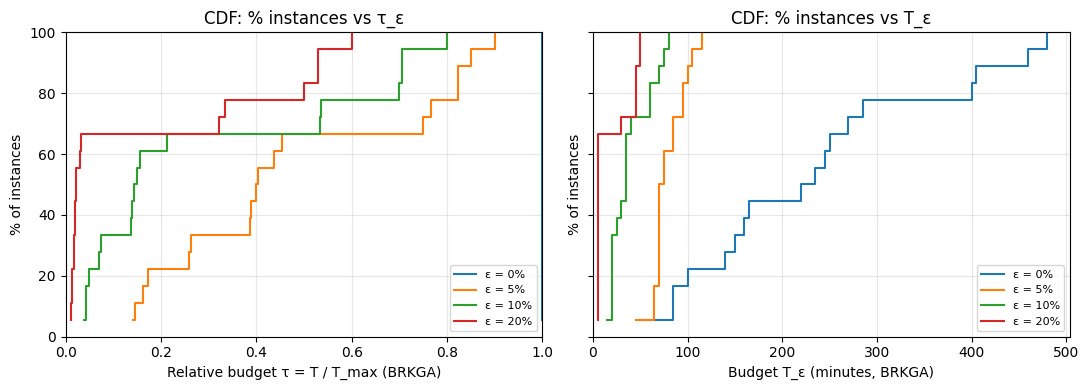

In [6]:
def build_tau_cdf_curve(tau_values: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    Thesis-style CDF: x = tau threshold, y = % instances with tau_eps <= x.
    """
    valid = np.sort(tau_values.dropna().astype(float).values)
    n = len(valid)
    if n == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    x = valid
    y = np.arange(1, n + 1, dtype=float) / n * 100.0
    return x, y


def plot_tau_eps_cdf(
    tau_table: pd.DataFrame,
    *,
    x_col: str,
    xlabel: str,
    method: str | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots()
    sub = tau_table if method is None else tau_table[tau_table["method"] == method]
    for eps in sorted(sub["eps"].unique()):
        part = sub[sub["eps"] == eps]
        x, y = build_tau_cdf_curve(part[x_col])
        ax.step(x, y, where="post", label=f"ε = {eps:.0%}")
    ax.set_xlim(0, 1 if x_col == "tau_eps" else None)
    ax.set_ylim(0, 100)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("% of instances")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

plot_tau_eps_cdf(
    tau_eps_table,
    x_col="tau_eps",
    xlabel=f"Relative budget τ = T / T_max ({METHOD_LABEL})",
    method=METHOD_LABEL if tau_eps_table["method"].nunique() == 1 else None,
    ax=axes[0],
)
axes[0].set_title("CDF: % instances vs τ_ε")

plot_tau_eps_cdf(
    tau_eps_table,
    x_col="T_eps",
    xlabel=f"Budget T_ε (minutes, {METHOD_LABEL})",
    method=METHOD_LABEL if tau_eps_table["method"].nunique() == 1 else None,
    ax=axes[1],
)
axes[1].set_title("CDF: % instances vs T_ε")

plt.tight_layout()
plt.show()

In [7]:
def compute_ratio_tau_eps(tau_table: pd.DataFrame) -> pd.DataFrame:
    """r_{i,m,eps} = tau_eps_{i,m} / min_m' tau_eps_{i,m'} per (case, eps)."""
    rows = []
    for (case, eps), grp in tau_table.groupby(["case_name", "eps"]):
        best = grp["tau_eps"].min()
        for _, row in grp.iterrows():
            ratio = row["tau_eps"] / best if best > 0 else np.nan
            rows.append(
                {
                    "case_name": case,
                    "method": row["method"],
                    "eps": eps,
                    "tau_eps": row["tau_eps"],
                    "ratio_tau": ratio,
                }
            )
    return pd.DataFrame(rows)


def build_ratio_profile_curve(ratios: pd.Series, kappa_grid: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    valid = ratios.dropna().astype(float).values
    if len(valid) == 0:
        return kappa_grid, np.zeros_like(kappa_grid)
    y = np.array([(valid <= k).mean() * 100.0 for k in kappa_grid])
    return kappa_grid, y


n_methods = tau_eps_table["method"].nunique()
if n_methods < 2:
    print(
        "Dolan–Moré ratio profile skipped: need ≥2 methods. "
        "Concatenate multiple load_sweep_csvs(...) results (see cell 2)."
    )
else:
    ratio_table = compute_ratio_tau_eps(tau_eps_table)
    fig, axes = plt.subplots(
        1,
        len(GAP_EPSILONS),
        figsize=(4 * len(GAP_EPSILONS), 4),
        sharey=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()
    for ax, eps in zip(axes_flat, sorted(GAP_EPSILONS)):
        part = ratio_table[ratio_table["eps"] == eps]
        max_ratio = max(part["ratio_tau"].max(), 1.0)
        kappa_grid = np.linspace(1.0, max_ratio * 1.05, 200)
        for method, sub in part.groupby("method"):
            _, y = build_ratio_profile_curve(sub["ratio_tau"], kappa_grid)
            ax.plot(kappa_grid, y, label=method)
        ax.set_xlim(left=1.0)
        if RATIO_PROFILE_LOG_X:
            ax.set_xscale("log")
        ax.set_xlabel("Performance ratio κ")
        ax.set_title(f"ε = {eps:.0%}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
    axes_flat[0].set_ylabel("% of instances")
    fig.suptitle("Dolan–Moré: % instances with τ_ε ratio ≤ κ", y=1.02)
    plt.tight_layout()
    plt.show()

Dolan–Moré ratio profile skipped: need ≥2 methods. Concatenate multiple load_sweep_csvs(...) results (see cell 2).


In [8]:
# Relative budget: binned and exact-T aggregation (lines + box plots)
df_rel = df.copy()
df_rel["rel_bin"] = (np.floor(df_rel["budget_frac"] / REL_BIN_WIDTH) * REL_BIN_WIDTH).astype(float)

g_bin_rel = (
    df_rel.groupby("rel_bin", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n=("profit_gap", "size"))
    .sort_values("rel_bin")
)
g_bin_rel["std_gap"] = g_bin_rel["std_gap"].fillna(0.0)

vc_rel = df_rel.groupby("budget_frac")["source_file"].nunique()
common_rel_T = vc_rel[vc_rel >= MIN_FILES_FOR_EXACT_T].index
df_exact_rel = df_rel[df_rel["budget_frac"].isin(common_rel_T)].copy()
g_exact_rel = (
    df_exact_rel.groupby("budget_frac", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n_files=("source_file", "nunique"))
    .sort_values("budget_frac")
)
g_exact_rel["std_gap"] = g_exact_rel["std_gap"].fillna(0.0)

print(f"Exact relative-T points with >= {MIN_FILES_FOR_EXACT_T} files: {len(g_exact_rel)}")


def boxplot_profit_gap_by_group(
    ax,
    frame: pd.DataFrame,
    group_col: str,
    *,
    box_width: float,
    min_n: int = 1,
    facecolor: str = "C0",
) -> None:
    """One box per distinct group_col value; x-axis position = group value."""
    groups = np.sort(frame[group_col].unique())
    data, positions = [], []
    for g in groups:
        vals = frame.loc[frame[group_col] == g, "profit_gap"].dropna().to_numpy()
        if len(vals) >= min_n:
            data.append(vals)
            positions.append(float(g))
    if not data:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
        return
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=True,
        manage_ticks=False,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(facecolor)
        patch.set_alpha(0.55)
    ax.set_xlim(0, 1)


Exact relative-T points with >= 3 files: 28


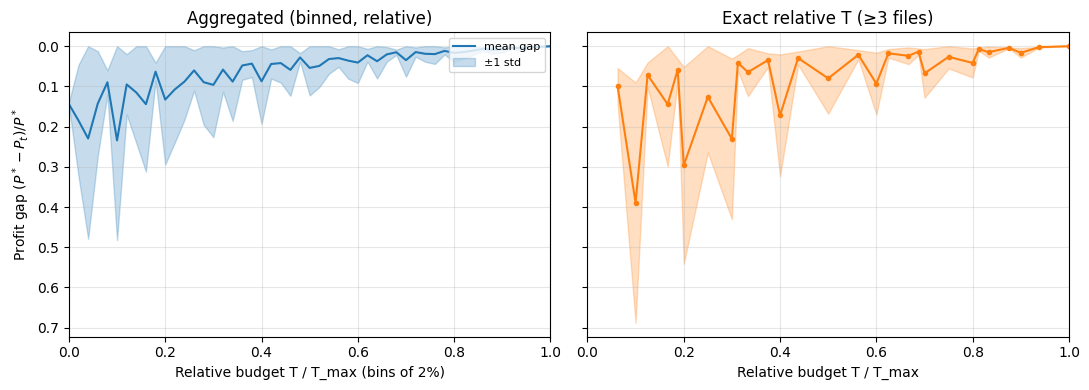

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax = axes[0]
ax.plot(g_bin_rel["rel_bin"], g_bin_rel["mean_gap"], color="C0", label="mean gap")
ax.fill_between(
    g_bin_rel["rel_bin"],
    (g_bin_rel["mean_gap"] - g_bin_rel["std_gap"]).clip(0, None),
    g_bin_rel["mean_gap"] + g_bin_rel["std_gap"],
    alpha=0.25,
    color="C0",
    label="±1 std",
)
ax.set_xlabel(f"Relative budget T / T_max (bins of {REL_BIN_WIDTH:.0%})")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Aggregated (binned, relative)")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(g_exact_rel["budget_frac"], g_exact_rel["mean_gap"], "o-", color="C1", markersize=3, label="mean gap")
ax.fill_between(
    g_exact_rel["budget_frac"],
    (g_exact_rel["mean_gap"] - g_exact_rel["std_gap"]).clip(0, None),
    g_exact_rel["mean_gap"] + g_exact_rel["std_gap"],
    alpha=0.25,
    color="C1",
)
ax.set_xlabel("Relative budget T / T_max")
ax.set_xlim(0, 1)
ax.set_title(f"Exact relative T (≥{MIN_FILES_FOR_EXACT_T} files)")
ax.grid(True, alpha=0.3)

axes[0].invert_yaxis()

plt.tight_layout()
plt.show()


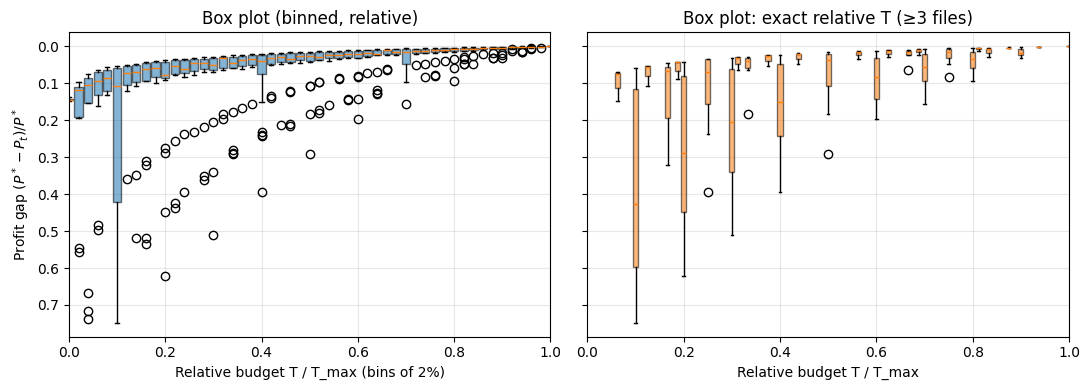

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax = axes[0]
boxplot_profit_gap_by_group(
    ax,
    df_rel,
    "rel_bin",
    box_width=REL_BIN_WIDTH * 0.85,
    facecolor="C0",
)
ax.set_xlabel(f"Relative budget T / T_max (bins of {REL_BIN_WIDTH:.0%})")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Box plot (binned, relative)")
ax.grid(True, alpha=0.3)

ax = axes[1]
fracs = np.sort(df_exact_rel["budget_frac"].unique())
exact_width = (
    0.85 * float(np.min(np.diff(fracs))) if len(fracs) > 1 else REL_BIN_WIDTH * 0.85
)
boxplot_profit_gap_by_group(
    ax,
    df_exact_rel,
    "budget_frac",
    box_width=exact_width,
    facecolor="C1",
)
ax.set_xlabel("Relative budget T / T_max")
ax.set_title(f"Box plot: exact relative T (≥{MIN_FILES_FOR_EXACT_T} files)")
ax.grid(True, alpha=0.3)

axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [11]:
# Binned aggregation (all instances pooled)
g_bin = (
    df.groupby("budget_bin", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n=("profit_gap", "size"))
    .sort_values("budget_bin")
)
g_bin["std_gap"] = g_bin["std_gap"].fillna(0.0)

# Exact budget_T: only T observed in >= MIN_FILES_FOR_EXACT_T CSVs
vc = df.groupby("budget_T")["source_file"].nunique()
common_T = vc[vc >= MIN_FILES_FOR_EXACT_T].index
g_exact = (
    df[df["budget_T"].isin(common_T)]
    .groupby("budget_T", as_index=False)
    .agg(mean_gap=("profit_gap", "mean"), std_gap=("profit_gap", "std"), n_files=("source_file", "nunique"))
    .sort_values("budget_T")
)
g_exact["std_gap"] = g_exact["std_gap"].fillna(0.0)

print(f"Exact-T points with >= {MIN_FILES_FOR_EXACT_T} files: {len(g_exact)}")

Exact-T points with >= 3 files: 81


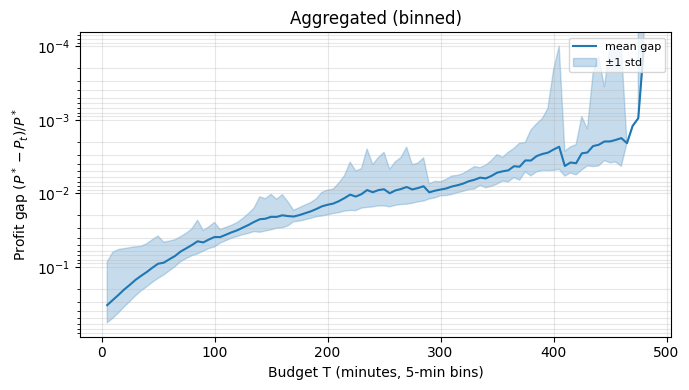

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(g_bin["budget_bin"], g_bin["mean_gap"], color="C0", label="mean gap")
ax.fill_between(
    g_bin["budget_bin"],
    (g_bin["mean_gap"] - g_bin["std_gap"]).clip(0, None),
    g_bin["mean_gap"] + g_bin["std_gap"],
    alpha=0.25,
    color="C0",
    label="±1 std",
)
ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Aggregated (binned)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
def pgfplots_method_tex(method_tex: str | None = None) -> str:
    """Resolve legend label even if the config cell was not re-run."""
    if method_tex is not None:
        return method_tex
    if "PGFPLOTS_METHOD_TEX" in globals():
        return PGFPLOTS_METHOD_TEX
    label = globals().get("METHOD_LABEL", "BRKGA")
    return rf"\textsc{{{label}}}"


def format_pgfplots_coordinates(
    curve: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    x_fmt: str = ".2f",
    y_fmt: str = ".3f",
) -> str:
    lines = []
    for _, row in curve.iterrows():
        lines.append(f"({row[x_col]:{x_fmt}},{row[y_col]:{y_fmt}})")
    return "\n".join(lines)


def export_profit_gap_binned_pgfplots(
    curve: pd.DataFrame,
    *,
    tex_path: Path,
    csv_path: Path | None = None,
    method_tex: str | None = None,
    x_col: str = "budget_bin",
    y_col: str = "mean_gap",
    std_col: str = "std_gap",
    caption: str | None = None,
    label: str = "fig:profit-gap-binned",
) -> Path:
    """Write a standalone figure snippet for thesis PGFPlots (mean + fill between ±1 std)."""
    method_tex = pgfplots_method_tex(method_tex)
    bin_minutes = globals().get("BIN_MINUTES", 5.0)
    method_label = globals().get("METHOD_LABEL", "BRKGA")
    curve = curve.sort_values(x_col).copy()
    curve["gap_lo"] = (curve[y_col] - curve[std_col]).clip(lower=0.0)
    curve["gap_hi"] = curve[y_col] + curve[std_col]

    if csv_path is not None:
        curve[[x_col, y_col, std_col, "gap_lo", "gap_hi"]].to_csv(csv_path, index=False)

    x_max = float(curve[x_col].max())
    coords_mean = format_pgfplots_coordinates(curve, x_col, y_col)
    coords_hi = format_pgfplots_coordinates(curve, x_col, "gap_hi")
    coords_lo = format_pgfplots_coordinates(curve, x_col, "gap_lo")
    if caption is None:
        caption = (
            "Mean profit gap "
            r"$\frac{P^{*}_I - P^I_T}{P^{*}_I}$ "
            f"with $\\pm 1$ std band vs budget $T$ "
            f"({bin_minutes:.0f}-min bins, {method_label})."
        )

    tex = rf"""\begin{{figure}}[h!]
    \centering
    \begin{{tikzpicture}}
\begin{{axis}}[
        name=plot1,
        ymin=1,
        ymax=0,
        xmin=0,
        xmax={x_max:.2f},
        scale only axis,
        height=5cm,
        width=7cm,
        ylabel=${{\frac{{P^{{*}}_I - P^I_T}}{{P^{{*}}_I}}}}$,
        xlabel=${{T}}$,
        legend style={{nodes={{scale=0.65, transform shape}}}},
        legend pos=north east,
        enlarge x limits=false]
    \addplot[name path=gapupper, draw=none] coordinates {{
{coords_hi}
    }};
    \addplot[name path=gaplower, draw=none] coordinates {{
{coords_lo}
    }};
    \addplot[blue!25, opacity=0.25] fill between[of=gapupper and gaplower];
    \addplot[densely dashdotted, very thick, blue] coordinates {{
{coords_mean}
    }};
    \legend{{{method_tex}}}
\end{{axis}}
    \end{{tikzpicture}}
    \caption{{{caption}}}
    \label{{{label}}}
\end{{figure}}
"""
    tex_path = Path(tex_path)
    tex_path.write_text(tex, encoding="utf-8")
    return tex_path


_export_pgf = globals().get("EXPORT_PGFPLOTS", True)
_tex_path = Path(globals().get("PGFPLOTS_TEX_PATH", "profit_gap_binned.tex"))
_csv_path = Path(globals().get("PGFPLOTS_CSV_PATH", "profit_gap_binned.csv"))

if _export_pgf:
    tex_out = export_profit_gap_binned_pgfplots(
        g_bin,
        tex_path=_tex_path,
        csv_path=_csv_path,
    )
    print(f"PGFPlots snippet: {tex_out.resolve()}")
    print(f"CSV: {_csv_path.resolve()}")
else:
    print("PGFPlots export disabled (EXPORT_PGFPLOTS=False).")

PGFPlots snippet: /home/matheusdiogenesandrade/Documentos/PhD/2024.2/COPAlgorithms/external/CBRP_original/reports/profit_gap_binned.tex
CSV: /home/matheusdiogenesandrade/Documentos/PhD/2024.2/COPAlgorithms/external/CBRP_original/reports/profit_gap_binned.csv


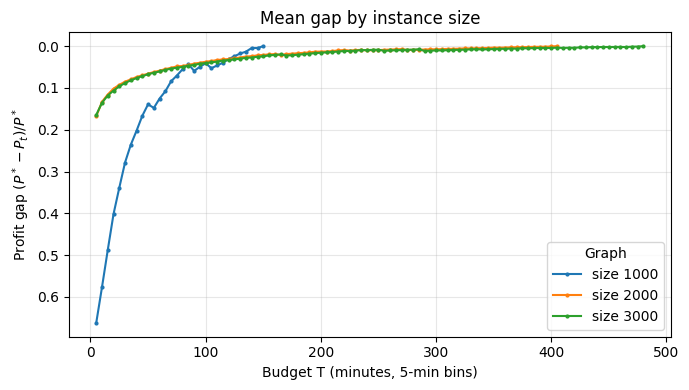

In [14]:
# Facet: one line per graph size (1000 / 2000 / 3000), binned mean gap
fig, ax = plt.subplots(figsize=(7, 4))
for sz, sub in df.groupby("size"):
    gb = (
        sub.groupby("budget_bin", as_index=False)
        .agg(mean_gap=("profit_gap", "mean"))
        .sort_values("budget_bin")
    )
    ax.plot(gb["budget_bin"], gb["mean_gap"], marker="o", markersize=2, label=f"size {sz}")

ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Mean gap by instance size")
ax.grid(True, alpha=0.3)
ax.legend(title="Graph")
ax.invert_yaxis()
plt.tight_layout()


In [15]:
plt.show()

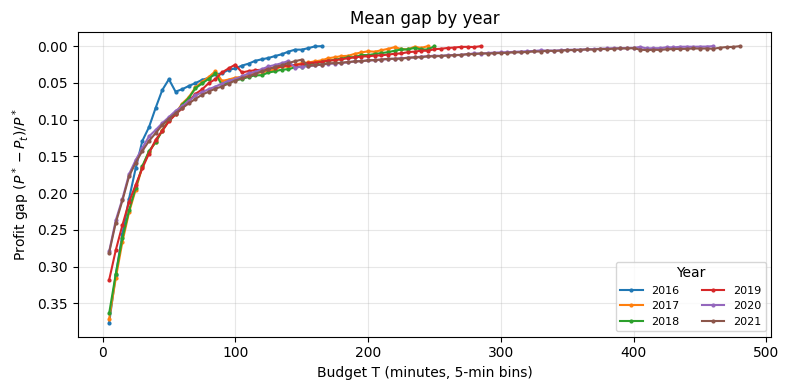

In [16]:
# Optional: mean gap by calendar year (3 instances per year)
fig, ax = plt.subplots(figsize=(8, 4))
for yr, sub in df.groupby("year"):
    gb = (
        sub.groupby("budget_bin", as_index=False)
        .agg(mean_gap=("profit_gap", "mean"))
        .sort_values("budget_bin")
    )
    ax.plot(gb["budget_bin"], gb["mean_gap"], marker="o", markersize=2, label=str(yr))

ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Profit gap $(P^* - P_t) / P^*$")
ax.set_title("Mean gap by year")
ax.grid(True, alpha=0.3)
ax.legend(title="Year", ncol=2, fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

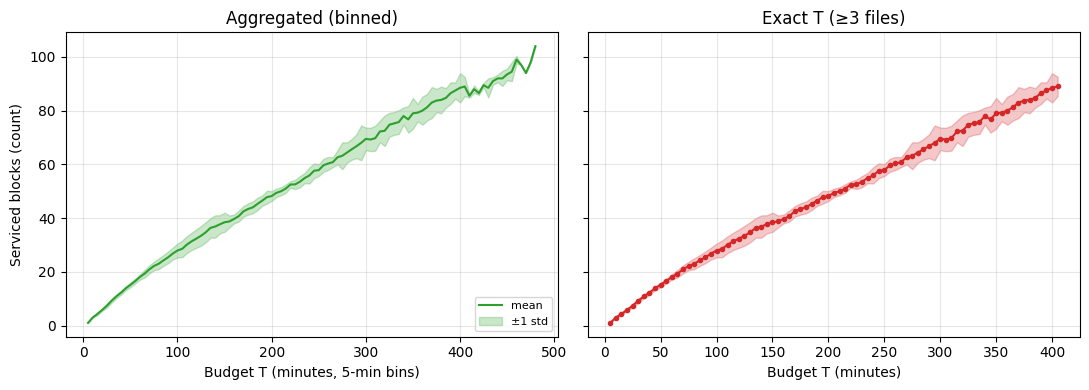

In [17]:
# Serviced blocks vs budget T (aggregated across sweep CSVs)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

g_bin_srv = (
    df.groupby("budget_bin", as_index=False)
    .agg(
        mean_srv=("num_serviced_blocks", "mean"),
        std_srv=("num_serviced_blocks", "std"),
    )
    .sort_values("budget_bin")
)
g_bin_srv["std_srv"] = g_bin_srv["std_srv"].fillna(0.0)

ax = axes[0]
ax.plot(g_bin_srv["budget_bin"], g_bin_srv["mean_srv"], color="C2", label="mean")
ax.fill_between(
    g_bin_srv["budget_bin"],
    (g_bin_srv["mean_srv"] - g_bin_srv["std_srv"]).clip(0, None),
    g_bin_srv["mean_srv"] + g_bin_srv["std_srv"],
    alpha=0.25,
    color="C2",
    label="±1 std",
)
ax.set_xlabel("Budget T (minutes, 5-min bins)")
ax.set_ylabel("Serviced blocks (count)")
ax.set_title("Aggregated (binned)")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=8)

vc_srv = df.groupby("budget_T")["source_file"].nunique()
common_T_srv = vc_srv[vc_srv >= MIN_FILES_FOR_EXACT_T].index
g_exact_srv = (
    df[df["budget_T"].isin(common_T_srv)]
    .groupby("budget_T", as_index=False)
    .agg(
        mean_srv=("num_serviced_blocks", "mean"),
        std_srv=("num_serviced_blocks", "std"),
    )
    .sort_values("budget_T")
)
g_exact_srv["std_srv"] = g_exact_srv["std_srv"].fillna(0.0)

ax = axes[1]
ax.plot(g_exact_srv["budget_T"], g_exact_srv["mean_srv"], "o-", color="C3", markersize=3)
ax.fill_between(
    g_exact_srv["budget_T"],
    (g_exact_srv["mean_srv"] - g_exact_srv["std_srv"]).clip(0, None),
    g_exact_srv["mean_srv"] + g_exact_srv["std_srv"],
    alpha=0.25,
    color="C3",
)
ax.set_xlabel("Budget T (minutes)")
ax.set_title(f"Exact T (≥{MIN_FILES_FOR_EXACT_T} files)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notes

- CPLEX column `relativeGAP` is left unused; the plotted gap is **economic** relative to \(P^\*\) from the rules above.
- If you add more sweep CSVs, widen `STEM_RE` or relax `parse_stem` accordingly.